In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles, make_blobs, make_moons
from sklearn.preprocessing import MinMaxScaler
np.random.seed(42)

# DBSCAN

In [34]:
X = np.array([
    (1.8, 4.5), (2.1, 4.8), (2.4, 4.2), (2.0, 5.2), (1.6, 4.0), (2.7, 4.6), (2.3, 5.0), (2.0, 2.5), (3.0, 3.2), (3.3, 2.8), (3.4, 3.1), (3.6, 2.8), (3.8, 3.4), (4.0, 3.6), (4.2, 3.8), (4.4, 3.6), (4.3, 4.1)
])

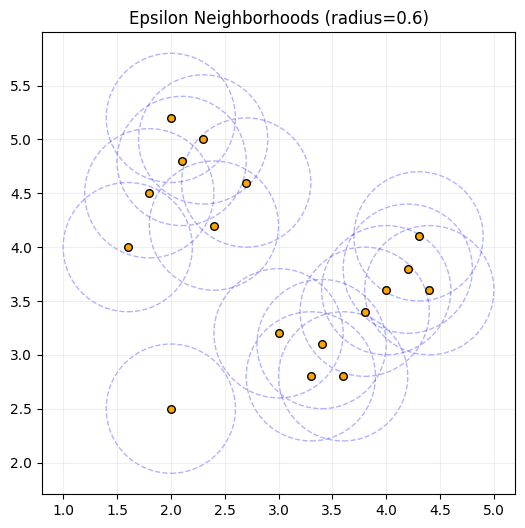

In [35]:
eps = 0.6
fig, ax = plt.subplots(figsize=(8, 6))

for point in X:
    circle = plt.Circle(point, eps, color='blue', fill=False, linestyle='--', alpha=0.3)
    ax.add_patch(circle)
    ax.scatter(point[0], point[1], c='orange', s=30, edgecolors='k', zorder=3)

ax.set_aspect('equal')
ax.set_title(f"Epsilon Neighborhoods (radius={eps})")
plt.grid(True, alpha=0.2)
plt.show()

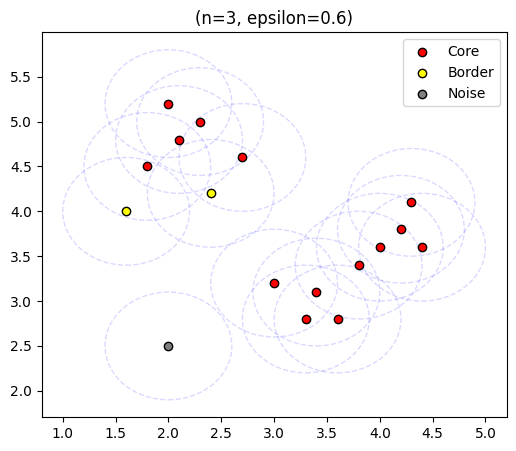

In [36]:
def add_circles(ax, data, radius):
    for p in data:
        ax.add_patch(plt.Circle(p, radius, color='blue', fill=False, linestyle='--', alpha=0.15))

eps, n_min = 0.6, 3

db = DBSCAN(eps=eps, min_samples=n_min).fit(X)
labels = db.labels_
core_mask = np.zeros_like(labels, dtype=bool)
core_mask[db.core_sample_indices_] = True

fig, ax = plt.subplots(figsize=(6, 5))
add_circles(ax, X, eps)

# Plot by type
plt.scatter(X[core_mask, 0], X[core_mask, 1], c='red', label='Core', edgecolors='k', zorder=4)
plt.scatter(X[~core_mask & (labels != -1), 0], X[~core_mask & (labels != -1), 1],
            c='yellow', label='Border', edgecolors='k', zorder=4)
plt.scatter(X[labels == -1, 0], X[labels == -1, 1], c='gray', label='Noise', edgecolors='k', zorder=4)

plt.title(f"(n={n_min}, epsilon={eps})")
plt.legend(); plt.show()

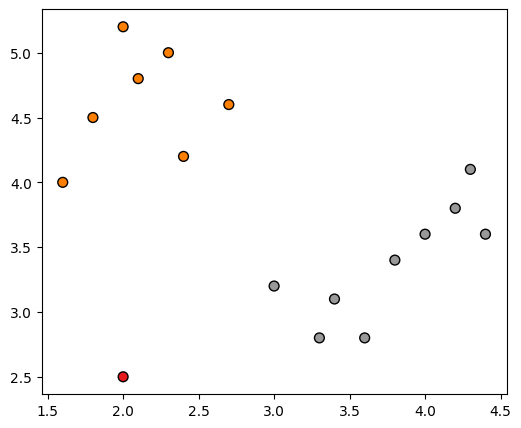

In [37]:
# simple plot without circles
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set1', s=50, edgecolors='k')
plt.show()

## Effect of $n$ (MinPts)

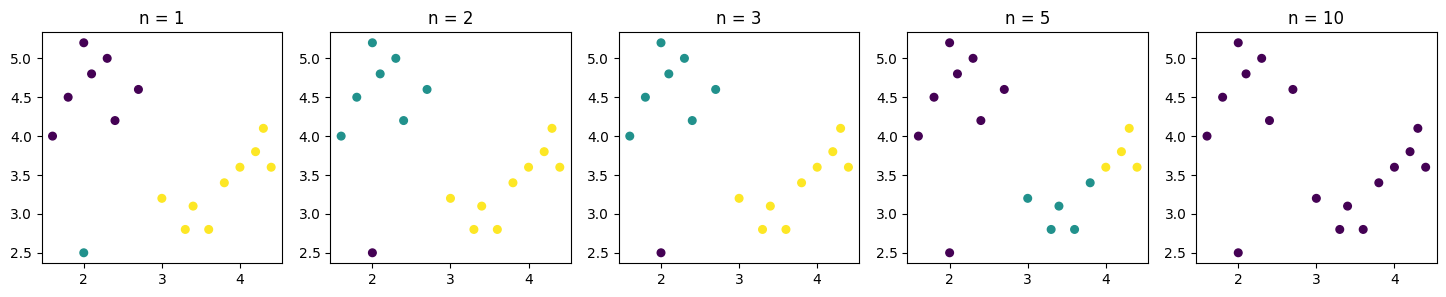

In [38]:
n_list = [1, 2, 3, 5, 10]
plt.figure(figsize=(18, 3))
for i, n in enumerate(n_list):
    res = DBSCAN(eps=0.6, min_samples=n).fit_predict(X)
    plt.subplot(1, 5, i+1)
    plt.scatter(X[:, 0], X[:, 1], c=res, cmap='viridis', s=30)
    plt.title(f"n = {n}")
plt.show()

## Effect of $\epsilon$

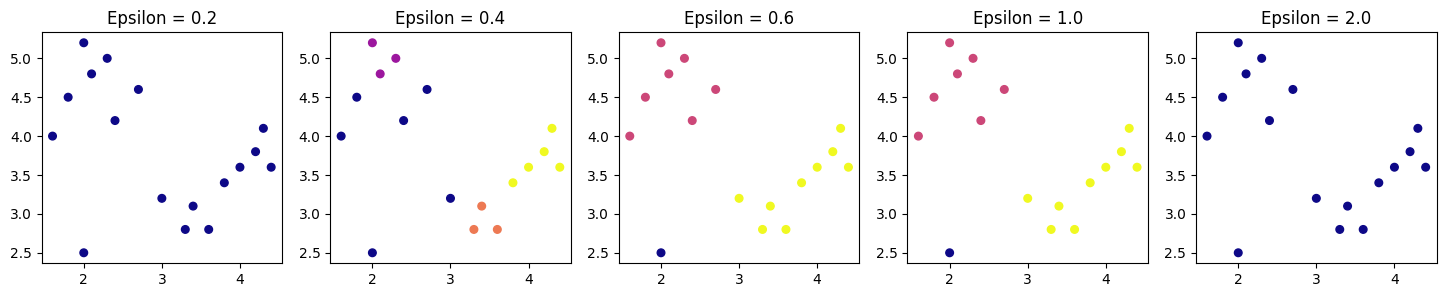

In [39]:
e_list = [0.2, 0.4, 0.6, 1.0, 2.0]
plt.figure(figsize=(18, 3))
for i, e in enumerate(e_list):
    res = DBSCAN(eps=e, min_samples=3).fit_predict(X)
    plt.subplot(1, 5, i+1)
    plt.scatter(X[:, 0], X[:, 1], c=res, cmap='plasma', s=30)
    plt.title(f"Epsilon = {e}")
plt.show()

## Effect of $n$ and $\epsilon$ together

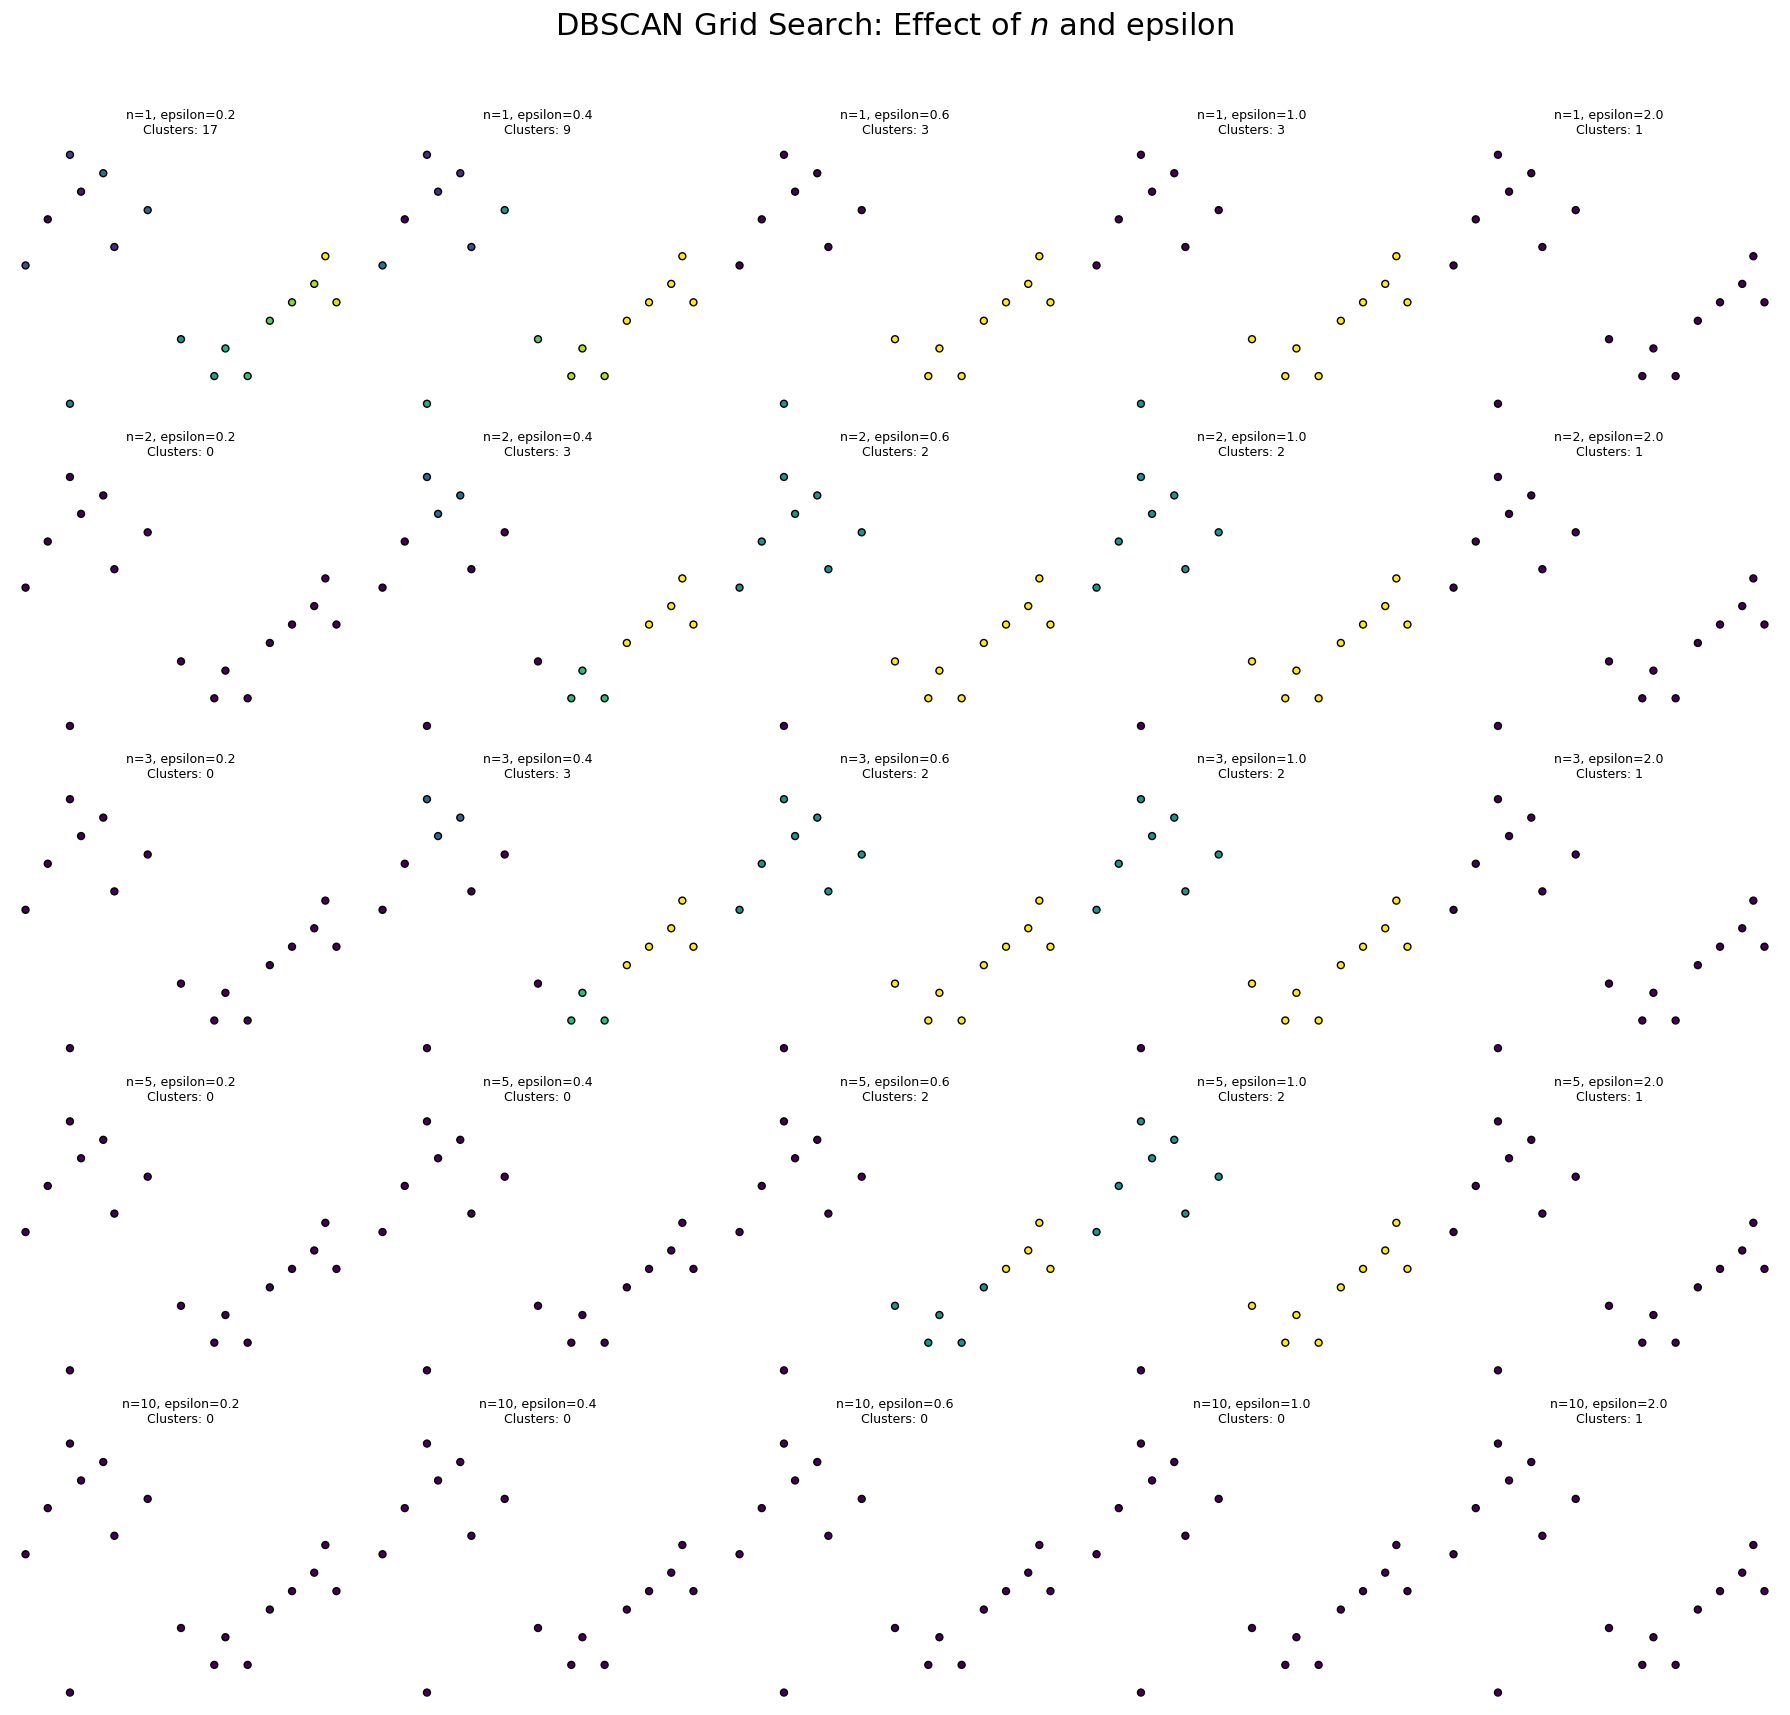

In [40]:
fig, axes = plt.subplots(5, 5, figsize=(18, 18))

for i, n in enumerate(n_list):
    for j, e in enumerate(e_list):
        db = DBSCAN(eps=e, min_samples=n).fit(X)
        labels = db.labels_

        ax = axes[i, j]
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=25, edgecolors='k')

        # Identification
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        ax.set_title(f"n={n}, epsilon={e}\nClusters: {n_clusters}", fontsize=9)
        ax.axis('off')

plt.suptitle("DBSCAN Grid Search: Effect of $n$ and epsilon", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## Where DBSCAN succeeds and fails

In [53]:
# donut-shaped data
X_circles, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
X_circles = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_circles)

# parallel lines
line1 = np.column_stack((np.linspace(0, 10, 200), np.zeros(200)))
line2 = np.column_stack((np.linspace(0, 10, 200), np.ones(200) * 2))
X_lines = np.vstack((line1, line2))
X_lines = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_lines)


# differently sized clusters
normal_data = np.random.normal(loc=10, scale=3, size=(50, 2))
anomaly_data = np.random.normal(loc=15, scale=0.5, size=(20, 2))
X_sizes = np.vstack((normal_data, anomaly_data))
X_sizes = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_sizes)

# moons
X_moon, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
X_moon = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_moon)

# outliers
X_outlier, _ = make_blobs(n_samples=50, centers=1, cluster_std=0.5, random_state=42)
X_outlier = np.vstack([X_outlier, [10, 10]]) # Add a far outlier
X_outlier = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_outlier)

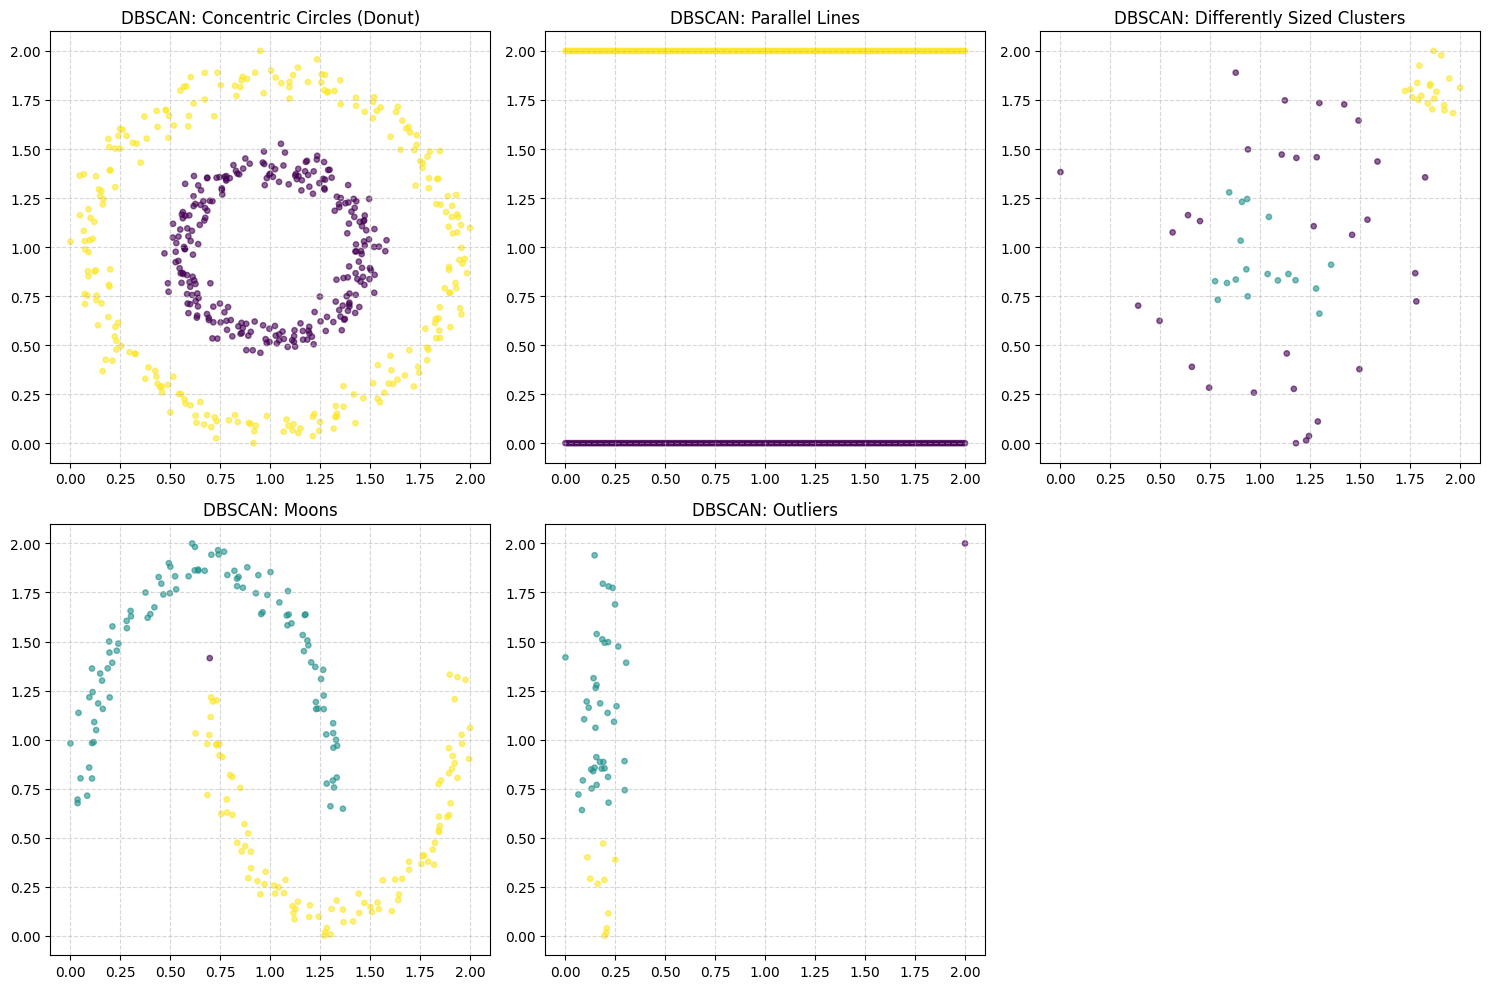

In [57]:
scenarios = [
    ("Concentric Circles (Donut)", X_circles),
    ("Parallel Lines", X_lines),
    ("Differently Sized Clusters", X_sizes),
    ("Moons", X_moon),
    ("Outliers", X_outlier)
]

plt.figure(figsize=(15, 10))

for i, (name, X) in enumerate(scenarios):
    model = DBSCAN(eps=0.2, min_samples=5)
    y_pred = model.fit_predict(X)

    plt.subplot(2, 3, i + 1)

    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6, s=15)

    plt.title(f"DBSCAN: {name}")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()